In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    'order_id': range(1, n+1),
    'customer_id': np.random.randint(1, 200, n),
    'order_date': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'amount': np.random.randint(10, 500, n),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Sports'], n)
})

data.head()

,order_id,customer_id,order_date,amount,product_category
0,1,103,2023-01-01,110,Home
1,2,180,2023-01-02,15,Clothing
2,3,93,2023-01-03,189,Electronics
3,4,15,2023-01-04,291,Electronics
4,5,107,2023-01-05,329,Clothing


In [2]:
data.to_csv("ecommerce_data.csv", index=False)

In [3]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")
data.to_sql("orders", conn, if_exists="replace", index=False)

1000

In [4]:
data['order_date'] = pd.to_datetime(data['order_date']).dt.strftime('%Y-%m-%d')

In [5]:
!pip install mysql-connector-python

   ---------------------------------------- 0.0/17.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
    --------------------------------------- 0.3/17.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.0 MB 209.2 kB/s eta 0:01:19
   - -------------------------------------- 0.5/17.0 MB 209.2 kB/s eta 0:01:19
   - -------------------------------------- 0.5/17.0 MB 209.2 kB/s eta 0:01:19
   - -------------------------------------- 0.5/17.0 MB 209.2 kB/s eta 0:01:19
   - -------------------------------------- 0.8/17.0 M

In [6]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Medicine16004**",
    database="ecommerce"
)

In [7]:
query = """
SELECT DATE_FORMAT(order_date, '%Y-%m') AS month,
       SUM(amount) AS revenue
FROM orders
GROUP BY month
ORDER BY month;
"""

df = pd.read_sql(query, conn)
df.head()

C:\Users\DEL\AppData\Local\Temp\ipykernel_13896\823051454.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,month,revenue
0,2023-01,8291.0
1,2023-02,6568.0
2,2023-03,6883.0
3,2023-04,8177.0
4,2023-05,7859.0


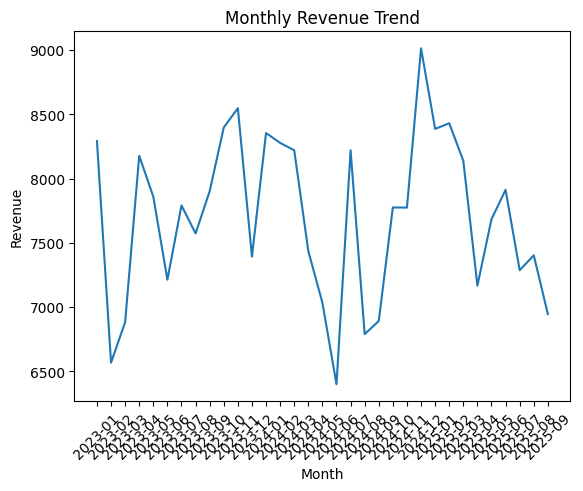

In [8]:
import matplotlib.pyplot as plt

plt.plot(df['month'], df['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()